In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os

# ==========================================
# 1. Define the Golden 8 Benchmark files
# ==========================================
# We explicitly list the 8 specific files chosen for the final presentation
# Ensure these files are placed inside the 'benchmark_data' folder
file_list = [
    'mmlu_external.csv',
    'gsm8k_external.csv',
    'hella_swag_external.csv',
    'gpqa_diamond.csv',
    'frontiermath.csv',
    'arc_agi_external.csv',
    'swe_bench_verified.csv',
    'chess_puzzles.csv'
]

folder_path = 'benchmark_data'

# ==========================================
# 2. Loop through and merge files
# ==========================================
all_data = []

for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    
    try:
        # Read a single file
        temp_df = pd.read_csv(file_path)
        
        # 🚨 Epoch AI uses different column names for scores across datasets.
        # This mapping dictionary normalizes them into our standard format.
        column_mapping = {
            'Model version': 'model_name',
            'Release date': 'release_date',
            'EM': 'score',                  # Used in MMLU, GSM8K
            'mean_score': 'score',          # Used in FrontierMath, GPQA, SWE-bench
            'Score': 'score',               # Used in ARC AGI
            'Overall accuracy': 'score'     # Used in HellaSwag
        }
        
        # Rename columns based on the mapping dictionary
        temp_df = temp_df.rename(columns=column_mapping)
        
        # Automatically extract Benchmark name from the filename 
        # (e.g., 'mmlu_external.csv' -> 'MMLU')
        bench_name = file_name.replace('.csv', '').replace('_external', '').replace('_verified', '').upper()
        temp_df['benchmark_name'] = bench_name
        
        # Keep only the necessary columns if they exist in the dataset
        if 'model_name' in temp_df.columns and 'score' in temp_df.columns and 'release_date' in temp_df.columns:
            temp_df = temp_df[['model_name', 'release_date', 'score', 'benchmark_name']]
            all_data.append(temp_df)
        else:
            print(f"⚠️ Warning: {file_name} is missing required columns. Available columns: {list(temp_df.columns)}")
            
    except FileNotFoundError:
        print(f"❌ Error: {file_name} not found in the '{folder_path}' folder!")
    except Exception as e:
        print(f"❌ Error reading {file_name}: {e}")

# Concatenate all valid DataFrames into one large master table
if all_data:
    df = pd.concat(all_data, ignore_index=True)

    # ==========================================
    # 3. Data Cleaning and Formatting
    # ==========================================
    # Convert release dates to standard datetime objects
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    
    # Convert scores to numeric values (handling any unexpected string characters)
    df['score'] = pd.to_numeric(df['score'], errors='coerce')

    # Standardize scores: convert 0~1 range decimals to 0~100 percentages
    if df['score'].max() <= 1.0:
        df['score'] = df['score'] * 100

    # Drop any invalid rows (e.g., models with no release date or no score)
    df = df.dropna(subset=['release_date', 'score'])

    print(f"✅ Successfully merged and cleaned data from {len(all_data)} benchmark files!")
else:
    print("❌ No valid data was loaded. Please check your CSV files and folder path.")

✅ Successfully merged and cleaned data from 8 benchmark files!


In [ ]:
# Define the Logistic function for the S-curve
def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def plot_lifecycle_curve(df, target_benchmark):
    b_df = df[df['benchmark_name'] == target_benchmark].copy()
    
    if b_df.empty:
        print(f"❌ No data found for {target_benchmark}")
        return

    b_df['months_since_start'] = (b_df['release_date'] - b_df['release_date'].min()).dt.days / 30.44
    
    x_data = b_df['months_since_start'].values
    y_data = b_df['score'].values

    # Fit the logistic curve
    try:
        # Initial guess: L=100 (max score), k=0.1 (growth rate), x0=median(x)
        popt, _ = curve_fit(logistic_func, x_data, y_data, p0=[100, 0.1, np.median(x_data)], bounds=([0, 0, -100], [105, 1, 1000]))
    except RuntimeError:
        print("⚠️ Could not fit the curve optimally.")
        popt = [100, 0.1, np.median(x_data)] # Fallback

    # Plotting
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(data=b_df, x='release_date', y='score', color='royalblue', s=100, alpha=0.8)
    
    # Generate a smooth X-axis for the curve (predicting 12 months into the future)
    x_smooth = np.linspace(x_data.min(), x_data.max() + 12, 100)
    y_smooth = logistic_func(x_smooth, *popt)
    
    date_smooth = b_df['release_date'].min() + pd.to_timedelta(x_smooth * 30.44, unit='D')
    
    # Plot the S-Curve
    plt.plot(date_smooth, y_smooth, color='red', linestyle='--', linewidth=3, label=f'Logistic Trend (Max: {popt[0]:.1f})')
    
    plt.title(f'Performance Lifecycle and Saturation of {target_benchmark}', fontsize=16, fontweight='bold')
    plt.xlabel('Release Date', fontsize=12)
    plt.ylabel('Benchmark Score', fontsize=12)
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.savefig(f'{target_benchmark}_lifecycle.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function to plot the lifecycle of MMLU
plot_lifecycle_curve(df, 'MMLU')

ValueError: Unit M is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns'

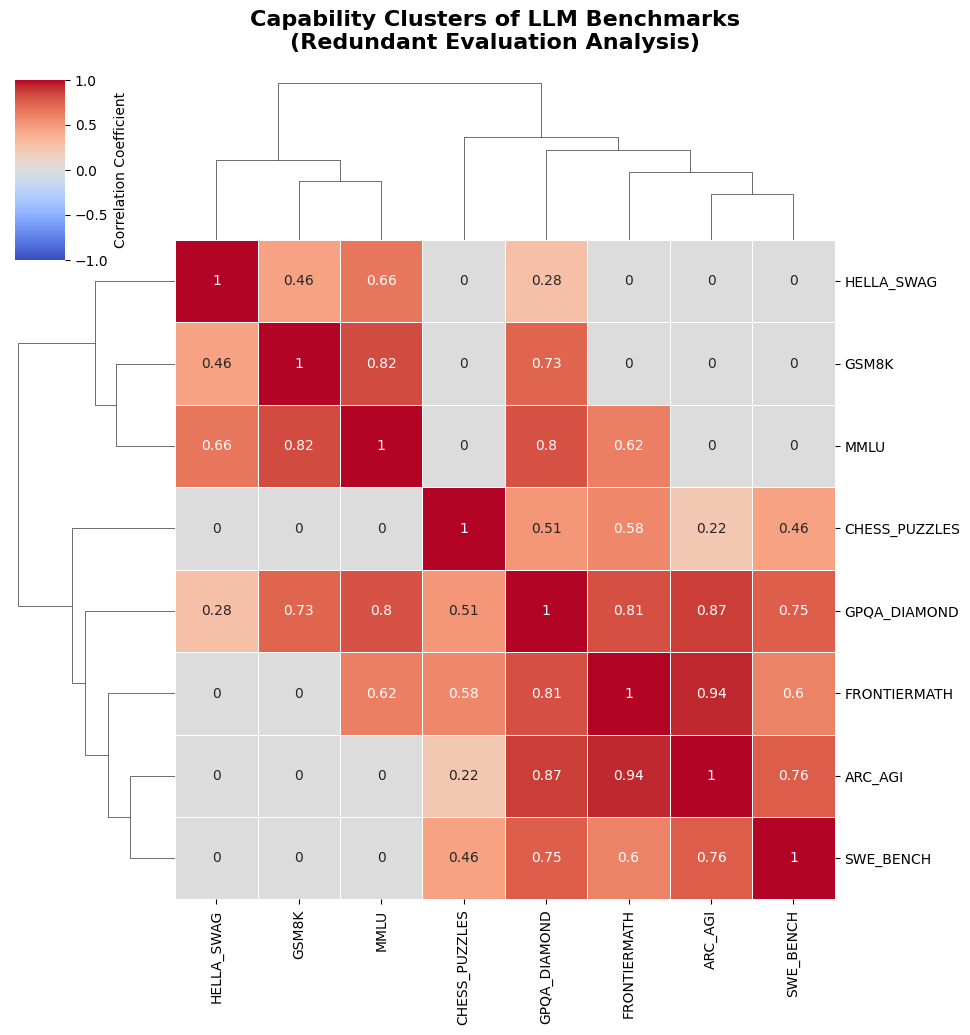

In [ ]:

# ==========================================
# 1. Structural Analysis: Model-by-Benchmark Matrix
# ==========================================
# Create a pivot table: Rows = Models, Columns = Benchmarks
pivot_df = df.pivot_table(index='model_name', columns='benchmark_name', values='score')

# Calculate the Pearson correlation matrix between benchmarks
corr_matrix = pivot_df.corr().fillna(0)

# ==========================================
# 2. Plot the Clustered Heatmap
# ==========================================
# Use seaborn's clustermap to automatically perform hierarchical clustering
g = sns.clustermap(
    corr_matrix, 
    annot=True,              # Show correlation numbers in the boxes
    cmap='coolwarm',         # Blue for negative, Red for positive correlation
    vmin=-1, vmax=1,         # Correlation ranges from -1 to 1
    linewidths=0.5,
    figsize=(10, 10),        # Make the figure slightly larger for 8 benchmarks
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Set the title
g.fig.suptitle('Capability Clusters of LLM Benchmarks\n(Redundant Evaluation Analysis)', y=1.05, fontsize=16, fontweight='bold')

# Remove the ugly default x and y axis labels
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')

# Save and show the plot
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()